In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import yfinance as yf

from pathlib import Path

In [2]:
TICKER = "SPY"

START = "2010-01-01"

END = None

In [3]:
df = yf.download(

    TICKER,

    start=START,

    end=END,

    auto_adjust=True

)

[*********************100%***********************]  1 of 1 completed


In [4]:
# Flatten MultiIndex columns

if isinstance(df.columns, pd.MultiIndex):

    df.columns = df.columns.get_level_values(0)

df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,84.578468,84.623245,83.220198,83.862019,118944600
2010-01-05,84.802383,84.839701,84.220268,84.526255,111579900
2010-01-06,84.862076,85.071040,84.653112,84.720276,116074400
2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100
2010-01-08,85.503891,85.541208,84.824759,84.996405,126402800


In [5]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,84.578468,84.623245,83.220198,83.862019,118944600
2010-01-05,84.802383,84.839701,84.220268,84.526255,111579900
2010-01-06,84.862076,85.071040,84.653112,84.720276,116074400
2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100
2010-01-08,85.503891,85.541208,84.824759,84.996405,126402800


In [6]:
print(df.shape)

df.tail()

(4159, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-07-13,749.169983,753.909973,748.000000,752.469971,44013600
2026-07-14,751.830017,753.340027,748.659973,750.909973,35143100
2026-07-15,754.809998,755.580017,750.200012,754.239990,43844800
2026-07-16,750.719971,754.570007,747.880005,752.760010,46409800
2026-07-17,743.289978,747.289978,740.799988,742.080017,62569200


In [7]:
df["Return"] = df["Close"].pct_change()

df["Log_Return"] = np.log(
    df["Close"] /
    df["Close"].shift(1)
)

In [8]:
df["SMA10"] = df["Close"].rolling(10).mean()

df["SMA20"] = df["Close"].rolling(20).mean()

df["SMA50"] = df["Close"].rolling(50).mean()

df["SMA100"] = df["Close"].rolling(100).mean()

df["SMA200"] = df["Close"].rolling(200).mean()

In [9]:
df["EMA10"] = df["Close"].ewm(span=10).mean()

df["EMA20"] = df["Close"].ewm(span=20).mean()

df["EMA50"] = df["Close"].ewm(span=50).mean()

In [10]:
df["Volatility10"] = (
    df["Return"]
    .rolling(10)
    .std()
)

df["Volatility20"] = (
    df["Return"]
    .rolling(20)
    .std()
)

df["Volatility50"] = (
    df["Return"]
    .rolling(50)
    .std()
)

In [11]:
df["Momentum5"] = (
    df["Close"] /
    df["Close"].shift(5)
) - 1

df["Momentum10"] = (
    df["Close"] /
    df["Close"].shift(10)
) - 1

df["Momentum20"] = (
    df["Close"] /
    df["Close"].shift(20)
) - 1

In [12]:
def compute_rsi(series, period=14):

    delta = series.diff()

    gain = delta.clip(lower=0)

    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()

    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    return rsi


df["RSI"] = compute_rsi(df["Close"])

In [13]:
ema12 = df["Close"].ewm(span=12).mean()

ema26 = df["Close"].ewm(span=26).mean()

df["MACD"] = ema12 - ema26

df["MACD_Signal"] = (
    df["MACD"]
    .ewm(span=9)
    .mean()
)

In [14]:
rolling_mean = (
    df["Close"]
    .rolling(20)
    .mean()
)

rolling_std = (
    df["Close"]
    .rolling(20)
    .std()
)

df["BB_Upper"] = (
    rolling_mean
    + 2 * rolling_std
)

df["BB_Lower"] = (
    rolling_mean
    - 2 * rolling_std
)

In [15]:
df["Volume_SMA20"] = (
    df["Volume"]
    .rolling(20)
    .mean()
)

df["Volume_Ratio"] = (
    df["Volume"] /
    df["Volume_SMA20"]
)

In [16]:
df = df.dropna()

print(df.shape)

df.head()

(3960, 28)


Price,Close,High,Low,Open,Volume,Return,Log_Return,SMA10,SMA20,SMA50,...,Momentum5,Momentum10,Momentum20,RSI,MACD,MACD_Signal,BB_Upper,BB_Lower,Volume_SMA20,Volume_Ratio
Date,,,,,,,,,,,,,,,,,,,,,
2010-10-18,89.534676,89.829894,88.800412,89.125910,141204800,0.004928,0.004916,88.529411,87.435583,84.467228,...,0.013974,0.039824,0.035636,73.656478,1.339000,1.263117,89.958583,84.912583,191024085.0,0.739199
2010-10-19,88.361366,89.209171,87.823911,88.709573,280604700,-0.013105,-0.013191,88.581642,87.539668,84.532958,...,-0.002393,0.005946,0.024127,62.583433,1.246805,1.259855,90.033473,85.045862,191634865.0,1.464267
2010-10-20,89.224327,89.655801,88.467355,88.520343,200051800,0.009766,0.009719,88.720927,87.708095,84.625134,...,-0.000424,0.015858,0.039235,69.120992,1.229205,1.253725,90.177947,85.238243,192071335.0,1.041549
2010-10-21,89.421112,90.147805,88.724699,89.625498,221585500,0.002206,0.002203,88.890486,87.921181,84.767627,...,0.005704,0.019328,0.050044,68.410022,1.217105,1.246401,90.192567,85.649796,193032895.0,1.147916
2010-10-22,89.587646,89.723902,89.322707,89.557367,108212400,0.001862,0.001861,89.027496,88.054787,84.923540,...,0.005522,0.015531,0.030744,75.785016,1.207040,1.238529,90.390547,85.719026,187959925.0,0.575721


In [17]:
forecast_horizon = 5


df["Future_Return"] = (
    df["Close"]
    .shift(-forecast_horizon)
    /
    df["Close"]
) - 1


df["Target"] = (
    df["Future_Return"] > 0
).astype(int)


df.tail()

Price,Close,High,Low,Open,Volume,Return,Log_Return,SMA10,SMA20,SMA50,...,Momentum20,RSI,MACD,MACD_Signal,BB_Upper,BB_Lower,Volume_SMA20,Volume_Ratio,Future_Return,Target
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-13,749.169983,753.909973,748.000000,752.469971,44013600,-0.007656,-0.007686,747.853015,743.998126,740.694133,...,0.018082,53.676895,3.579411,2.885924,758.410940,729.585312,56553570.0,0.778264,NaN,0
2026-07-14,751.830017,753.340027,748.659973,750.909973,35143100,0.003551,0.003544,748.936017,744.597427,741.394468,...,0.016201,66.050984,3.702148,3.049169,759.277254,729.917601,55456750.0,0.633703,NaN,0
2026-07-15,754.809998,755.580017,750.200012,754.239990,43844800,0.003964,0.003956,749.740015,744.693408,742.114703,...,0.002550,68.129088,3.993840,3.238103,759.624488,729.762328,54640170.0,0.802428,NaN,0
2026-07-16,750.719971,754.570007,747.880005,752.760010,46409800,-0.005419,-0.005433,750.236011,744.809308,742.805803,...,0.003097,63.131767,3.850589,3.360600,759.896764,729.721852,53606005.0,0.865757,NaN,0
2026-07-17,743.289978,747.289978,740.799988,742.080017,62569200,-0.009897,-0.009946,750.087006,745.021005,743.233398,...,0.005729,61.061240,3.101768,3.308834,759.885733,730.156277,52437205.0,1.193221,NaN,0


In [18]:
print(
    df["Target"]
    .value_counts()
)


print(
    df["Target"]
    .value_counts(normalize=True)
)

Target
1    2428
0    1532
Name: count, dtype: int64
Target
1    0.613131
0    0.386869
Name: proportion, dtype: float64


In [19]:
df = df.dropna()

df = df.drop(
    columns=[
        "Future_Return"
    ]
)

print(df.shape)

(3955, 29)


In [20]:
features = [
    col
    for col in df.columns
    if col not in [
        "Target"
    ]
]


X = df[features]

y = df["Target"]

In [21]:
split_date = "2022-01-01"


X_train = X.loc[
    X.index < split_date
]


X_test = X.loc[
    X.index >= split_date
]


y_train = y.loc[
    y.index < split_date
]


y_test = y.loc[
    y.index >= split_date
]


print(
    X_train.shape,
    X_test.shape
)

(2822, 28) (1133, 28)


In [22]:
scale_pos_weight = (
    y_train.value_counts()[0]
    /
    y_train.value_counts()[1]
)


print(scale_pos_weight)

0.607977207977208


In [23]:
from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

In [24]:
model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.03,

    max_depth=4,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    eval_metric="logloss"

)


model.fit(

    X_train,

    y_train

)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [25]:
probabilities = model.predict_proba(
    X_test
)[:,1]


predictions = (
    probabilities > 0.5
).astype(int)

In [26]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        predictions
    )
)


print(
    "Precision:",
    precision_score(
        y_test,
        predictions
    )
)


print(
    "Recall:",
    recall_score(
        y_test,
        predictions
    )
)


print(
    "F1:",
    f1_score(
        y_test,
        predictions
    )
)


print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        probabilities
    )
)


print(
    confusion_matrix(
        y_test,
        predictions
    )
)

Accuracy: 0.502206531332745
Precision: 0.5880452342487884
Recall: 0.5408618127786032
F1: 0.5634674922600619
ROC AUC: 0.4871729439886297
[[205 255]
 [309 364]]


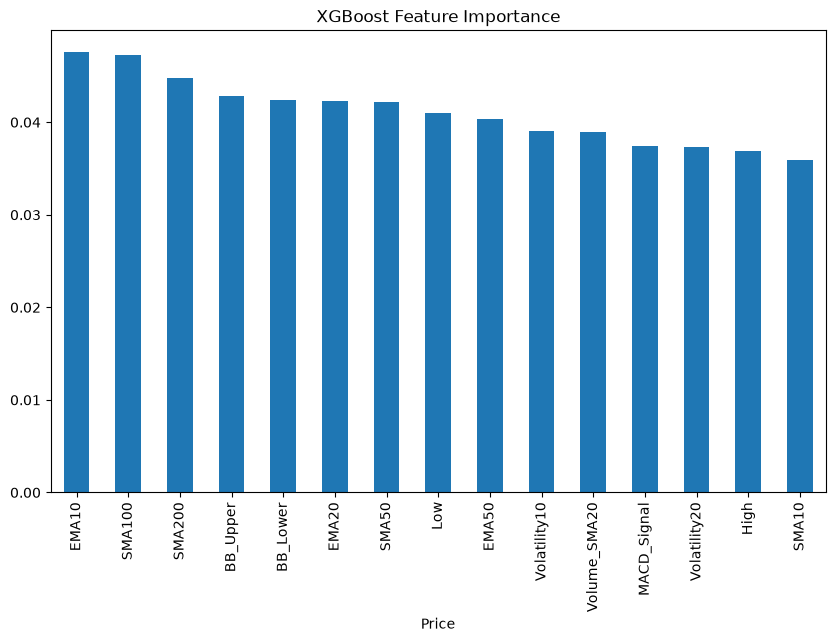

In [27]:
import matplotlib.pyplot as plt


importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)


importance = importance.sort_values(
    ascending=False
)


plt.figure(figsize=(10,6))

importance.head(15).plot(
    kind="bar"
)

plt.title(
    "XGBoost Feature Importance"
)

plt.show()

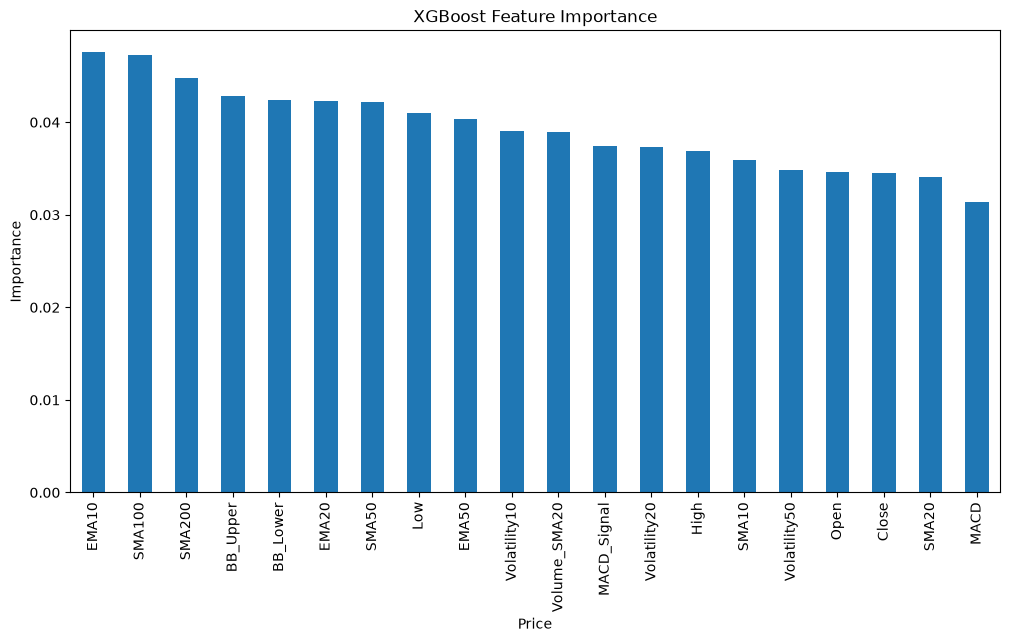

Price
EMA10           0.047538
SMA100          0.047221
SMA200          0.044811
BB_Upper        0.042872
BB_Lower        0.042385
EMA20           0.042305
SMA50           0.042159
Low             0.040993
EMA50           0.040401
Volatility10    0.039027
Volume_SMA20    0.038977
MACD_Signal     0.037449
Volatility20    0.037320
High            0.036919
SMA10           0.035910
Volatility50    0.034830
Open            0.034572
Close           0.034476
SMA20           0.034058
MACD            0.031328
dtype: float32

In [28]:
import matplotlib.pyplot as plt


importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)


importance = importance.sort_values(
    ascending=False
)


plt.figure(figsize=(12,6))


importance.head(20).plot(
    kind="bar"
)


plt.title(
    "XGBoost Feature Importance"
)


plt.ylabel(
    "Importance"
)


plt.show()


importance.head(20)

In [29]:
forecast_horizon = 5

target_threshold = 0.005


df["Future_Return"] = (
    df["Close"]
    .shift(-forecast_horizon)
    /
    df["Close"]
) - 1


df["Target"] = (
    df["Future_Return"] > target_threshold
).astype(int)


df = df.dropna()


print(
    df["Target"].value_counts()
)


print(
    df["Target"].value_counts(normalize=True)
)

Target
0    2018
1    1932
Name: count, dtype: int64
Target
0    0.510886
1    0.489114
Name: proportion, dtype: float64


In [30]:
features = [
    c for c in df.columns
    if c not in [
        "Target",
        "Future_Return"
    ]
]


X = df[features]

y = df["Target"]



split_date = "2022-01-01"


X_train = X.loc[
    X.index < split_date
]


X_test = X.loc[
    X.index >= split_date
]


y_train = y.loc[
    y.index < split_date
]


y_test = y.loc[
    y.index >= split_date
]


print(
    X_train.shape,
    X_test.shape
)

(2822, 28) (1128, 28)


In [31]:
scale_pos_weight = (
    y_train.value_counts()[0]
    /
    y_train.value_counts()[1]
)


print(
    scale_pos_weight
)

1.0449275362318842


In [32]:
from xgboost import XGBClassifier


model_v2 = XGBClassifier(

    n_estimators=500,

    learning_rate=0.03,

    max_depth=3,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    eval_metric="logloss"

)


model_v2.fit(
    X_train,
    y_train
)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [33]:
probabilities_v2 = model_v2.predict_proba(
    X_test
)[:,1]


predictions_v2 = (
    probabilities_v2 > 0.5
).astype(int)

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


print(
    "Accuracy:",
    accuracy_score(
        y_test,
        predictions_v2
    )
)


print(
    "Precision:",
    precision_score(
        y_test,
        predictions_v2
    )
)


print(
    "Recall:",
    recall_score(
        y_test,
        predictions_v2
    )
)


print(
    "F1:",
    f1_score(
        y_test,
        predictions_v2
    )
)


print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        probabilities_v2
    )
)


print(
    confusion_matrix(
        y_test,
        predictions_v2
    )
)

Accuracy: 0.5
Precision: 0.4863013698630137
Recall: 0.3858695652173913
F1: 0.4303030303030303
ROC AUC: 0.507067104468599
[[351 225]
 [339 213]]


In [35]:
df["Price_SMA20_Distance"] = (
    df["Close"] /
    df["SMA20"]
) - 1


df["Price_SMA50_Distance"] = (
    df["Close"] /
    df["SMA50"]
) - 1


df["Price_SMA200_Distance"] = (
    df["Close"] /
    df["SMA200"]
) - 1

In [36]:
df["SMA20_SMA50"] = (
    df["SMA20"] /
    df["SMA50"]
) - 1


df["SMA50_SMA200"] = (
    df["SMA50"] /
    df["SMA200"]
) - 1

In [37]:
df["Rolling_Sharpe20"] = (
    df["Return"]
    .rolling(20)
    .mean()
    /
    df["Return"]
    .rolling(20)
    .std()
)

In [38]:
rolling_max = (
    df["Close"]
    .rolling(50)
    .max()
)


df["Drawdown50"] = (
    df["Close"] /
    rolling_max
) - 1

In [39]:
df["Volatility_Regime"] = (
    df["Volatility10"] /
    df["Volatility50"]
)

In [40]:
df["Daily_Range"] = (
    df["High"] -
    df["Low"]
) / df["Close"]


df["Open_Close_Return"] = (
    df["Close"] -
    df["Open"]
) / df["Open"]

In [41]:
df = df.dropna()

print(df.shape)

(3901, 40)


In [42]:
forecast_horizon = 5

target_threshold = 0.005


df["Future_Return"] = (
    df["Close"].shift(-forecast_horizon)
    /
    df["Close"]
) - 1


df["Target"] = (
    df["Future_Return"] > target_threshold
).astype(int)


df = df.dropna()


print(df.shape)

print(
    df["Target"].value_counts(normalize=True)
)

(3896, 40)
Target
0    0.51232
1    0.48768
Name: proportion, dtype: float64


In [43]:
features = [
    c for c in df.columns
    if c not in [
        "Target",
        "Future_Return"
    ]
]


X = df[features]

y = df["Target"]

In [44]:
split_date = "2022-01-01"


X_train = X.loc[
    X.index < split_date
]


X_test = X.loc[
    X.index >= split_date
]


y_train = y.loc[
    y.index < split_date
]


y_test = y.loc[
    y.index >= split_date
]


print(
    X_train.shape,
    X_test.shape
)

(2773, 38) (1123, 38)


In [45]:
scale_pos_weight = (
    y_train.value_counts()[0]
    /
    y_train.value_counts()[1]
)


print(scale_pos_weight)

1.0510355029585798


In [46]:
from xgboost import XGBClassifier


model_v3 = XGBClassifier(

    n_estimators=600,

    learning_rate=0.02,

    max_depth=3,

    min_child_weight=5,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0.1,

    reg_lambda=1,

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    eval_metric="logloss"

)


model_v3.fit(
    X_train,
    y_train
)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=None,
              num_parallel_tree=None, ...)

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


probabilities_v3 = model_v3.predict_proba(
    X_test
)[:,1]


predictions_v3 = (
    probabilities_v3 > 0.5
).astype(int)



print(
    "Accuracy:",
    accuracy_score(
        y_test,
        predictions_v3
    )
)


print(
    "Precision:",
    precision_score(
        y_test,
        predictions_v3
    )
)


print(
    "Recall:",
    recall_score(
        y_test,
        predictions_v3
    )
)


print(
    "F1:",
    f1_score(
        y_test,
        predictions_v3
    )
)


print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        probabilities_v3
    )
)


print(
    confusion_matrix(
        y_test,
        predictions_v3
    )
)

Accuracy: 0.4942119323241318
Precision: 0.47863247863247865
Recall: 0.40875912408759124
F1: 0.4409448818897638
ROC AUC: 0.529787369089178
[[331 244]
 [324 224]]


In [48]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

In [49]:
param_grid = {

    "n_estimators": [
        300,
        500,
        800
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05
    ],

    "max_depth": [
        2,
        3,
        4
    ],

    "min_child_weight": [
        1,
        5,
        10
    ],

    "subsample": [
        0.7,
        0.8,
        1.0
    ],

    "colsample_bytree": [
        0.7,
        0.8,
        1.0
    ]
}

In [50]:
tscv = TimeSeriesSplit(
    n_splits=5
)

In [51]:
from xgboost import XGBClassifier


xgb = XGBClassifier(

    random_state=42,

    eval_metric="logloss",

    scale_pos_weight=scale_pos_weight
)

In [52]:
random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_grid,

    n_iter=30,

    scoring="roc_auc",

    cv=tscv,

    verbose=1,

    random_state=42,

    n_jobs=-1
)


random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=Non...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                

In [53]:
print(
    random_search.best_params_
)


print(
    random_search.best_score_
)

{'subsample': 0.8, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
0.585660341490712


In [54]:
best_model = random_search.best_estimator_

In [55]:
best_probabilities = best_model.predict_proba(
    X_test
)[:,1]


best_predictions = (
    best_probabilities > 0.5
).astype(int)

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


print(
    "Accuracy:",
    accuracy_score(
        y_test,
        best_predictions
    )
)


print(
    "Precision:",
    precision_score(
        y_test,
        best_predictions
    )
)


print(
    "Recall:",
    recall_score(
        y_test,
        best_predictions
    )
)


print(
    "F1:",
    f1_score(
        y_test,
        best_predictions
    )
)


print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        best_probabilities
    )
)


print(
    confusion_matrix(
        y_test,
        best_predictions
    )
)

Accuracy: 0.5164737310774711
Precision: 0.5046382189239332
Recall: 0.49635036496350365
F1: 0.500459981600736
ROC AUC: 0.5263313233894003
[[308 267]
 [276 272]]


In [57]:
import numpy as np

from sklearn.metrics import f1_score


thresholds = np.arange(
    0.3,
    0.7,
    0.01
)


scores = []


for t in thresholds:

    preds = (
        best_probabilities >= t
    ).astype(int)


    score = f1_score(
        y_test,
        preds
    )

    scores.append(score)



best_threshold = thresholds[
    np.argmax(scores)
]


best_f1 = max(scores)


print(
    "Best Threshold:",
    best_threshold
)


print(
    "Best F1:",
    best_f1
)

Best Threshold: 0.3
Best F1: 0.5662847790507365


In [58]:
optimized_predictions = (
    best_probabilities >= best_threshold
).astype(int)


print(
    confusion_matrix(
        y_test,
        optimized_predictions
    )
)

[[247 328]
 [202 346]]


In [59]:
test_results = X_test.copy()


test_results["Actual_Return"] = (
    df.loc[X_test.index, "Return"]
)


test_results["Probability"] = (
    best_probabilities
)


test_results["Signal"] = (
    best_probabilities >= best_threshold
).astype(int)


test_results.head()

Price,Close,High,Low,Open,Volume,Return,Log_Return,SMA10,SMA20,SMA50,...,SMA20_SMA50,SMA50_SMA200,Rolling_Sharpe20,Drawdown50,Volatility_Regime,Daily_Range,Open_Close_Return,Actual_Return,Probability,Signal
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,449.486450,449.618193,445.854516,448.159751,72668200,0.005790,0.005773,443.809879,440.472147,436.442236,...,0.009234,0.066470,0.281676,0.000000,0.965736,0.008373,0.002960,0.005790,0.243794,0
2022-01-04,449.335785,451.622240,447.482174,450.907132,71178700,-0.000335,-0.000335,445.933524,441.430287,436.931819,...,0.010296,0.066577,0.225854,-0.000335,0.806525,0.009214,-0.003485,-0.000335,0.299803,0
2022-01-05,440.707611,449.740439,440.613513,448.968878,104538900,-0.019202,-0.019389,446.434085,441.512115,437.203270,...,0.009855,0.066226,0.023397,-0.019531,0.971575,0.020710,-0.018401,-0.019202,0.271473,0
2022-01-06,440.293610,443.003461,437.931894,440.246575,86858900,-0.000939,-0.000940,446.457605,441.515114,437.458754,...,0.009273,0.065819,0.005407,-0.020452,0.913943,0.011519,0.000107,-0.000939,0.383341,1
2022-01-07,438.552979,441.479252,437.198053,440.303103,85111600,-0.003953,-0.003961,446.033246,441.579689,437.717303,...,0.008824,0.065469,0.019624,-0.024324,0.892163,0.009762,-0.003975,-0.003953,0.554423,1


In [60]:
test_results["Strategy_Return"] = (
    test_results["Signal"]
    *
    test_results["Actual_Return"]
)


test_results[
    [
        "Actual_Return",
        "Probability",
        "Signal",
        "Strategy_Return"
    ]
].head()

Price,Actual_Return,Probability,Signal,Strategy_Return
Date,,,,
2022-01-03,0.005790,0.243794,0,0.000000
2022-01-04,-0.000335,0.299803,0,-0.000000
2022-01-05,-0.019202,0.271473,0,-0.000000
2022-01-06,-0.000939,0.383341,1,-0.000939
2022-01-07,-0.003953,0.554423,1,-0.003953


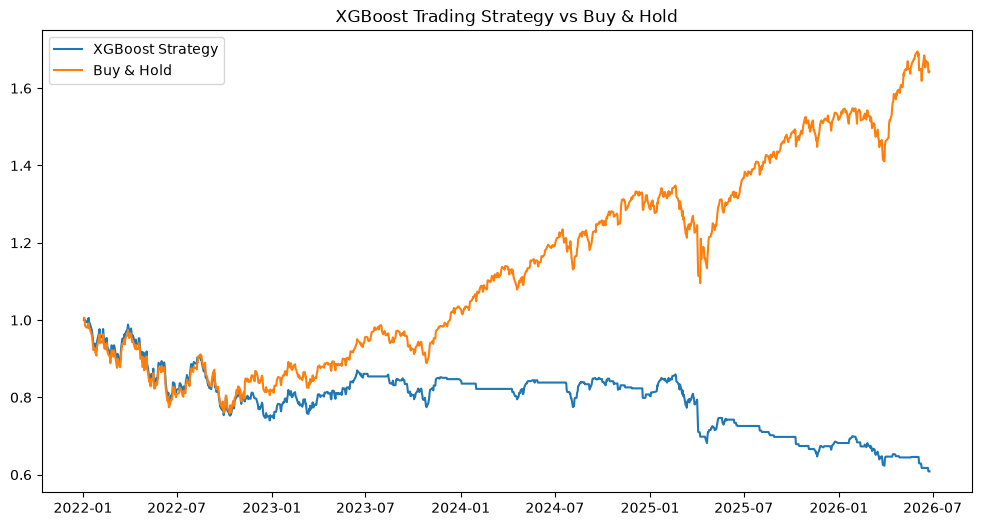

In [61]:
import matplotlib.pyplot as plt


test_results["Strategy_Equity"] = (
    1 +
    test_results["Strategy_Return"]
).cumprod()


test_results["BuyHold_Equity"] = (
    1 +
    test_results["Actual_Return"]
).cumprod()



plt.figure(figsize=(12,6))


plt.plot(
    test_results["Strategy_Equity"],
    label="XGBoost Strategy"
)


plt.plot(
    test_results["BuyHold_Equity"],
    label="Buy & Hold"
)


plt.legend()

plt.title(
    "XGBoost Trading Strategy vs Buy & Hold"
)

plt.show()

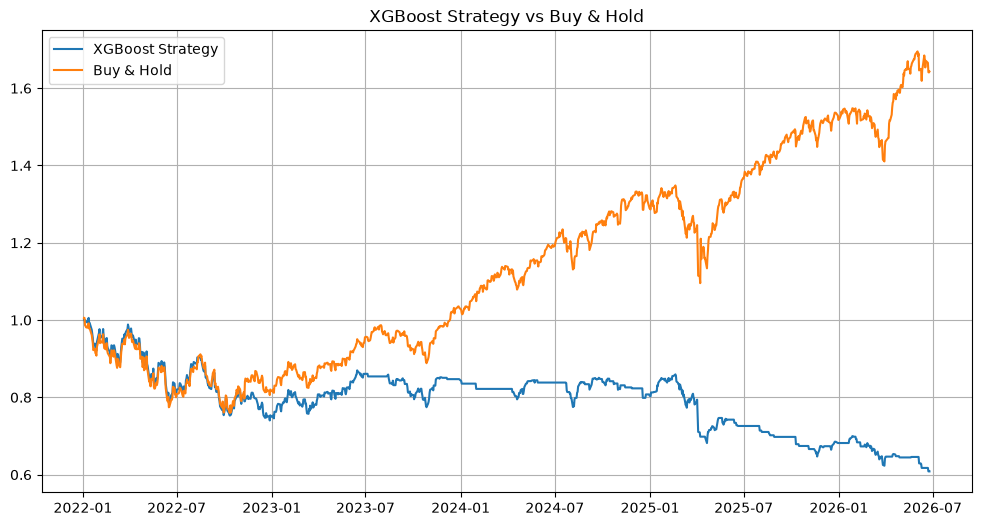

In [62]:
test_results["Strategy_Equity"] = (
    1 +
    test_results["Strategy_Return"]
).cumprod()


test_results["BuyHold_Equity"] = (
    1 +
    test_results["Actual_Return"]
).cumprod()


import matplotlib.pyplot as plt


plt.figure(figsize=(12,6))


plt.plot(
    test_results.index,
    test_results["Strategy_Equity"],
    label="XGBoost Strategy"
)


plt.plot(
    test_results.index,
    test_results["BuyHold_Equity"],
    label="Buy & Hold"
)


plt.legend()

plt.title(
    "XGBoost Strategy vs Buy & Hold"
)

plt.grid()

plt.show()

In [63]:
import numpy as np


def performance_metrics(returns):

    annual_return = (
        (1 + returns.mean()) ** 252
        - 1
    )


    annual_volatility = (
        returns.std()
        *
        np.sqrt(252)
    )


    sharpe = (
        annual_return /
        annual_volatility
    )


    cumulative = (
        1 + returns
    ).cumprod()


    peak = cumulative.cummax()


    drawdown = (
        cumulative /
        peak
    ) - 1


    max_drawdown = drawdown.min()


    return {
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe,
        "Maximum Drawdown": max_drawdown
    }

In [64]:
xgb_metrics = performance_metrics(
    test_results["Strategy_Return"]
)


xgb_metrics

{'Annual Return': np.float64(-0.09542012491764762),
 'Annual Volatility': np.float64(0.14941499856770185),
 'Sharpe Ratio': np.float64(-0.6386248089706439),
 'Maximum Drawdown': np.float64(-0.39495547521847385)}

In [65]:
buyhold_metrics = performance_metrics(
    test_results["Actual_Return"]
)


buyhold_metrics

{'Annual Return': np.float64(0.13531595771138782),
 'Annual Volatility': np.float64(0.1762671038737716),
 'Sharpe Ratio': np.float64(0.7676756169335505),
 'Maximum Drawdown': np.float64(-0.2449639386094098)}

In [66]:
test_results["Position"] = (
    test_results["Probability"]
    - 0.5
)

In [67]:
test_results["Weighted_Return"] = (
    test_results["Position"]
    *
    test_results["Actual_Return"]
)

In [68]:
weighted_metrics = performance_metrics(
    test_results["Weighted_Return"]
)


weighted_metrics

{'Annual Return': np.float64(-0.157319439349083),
 'Annual Volatility': np.float64(0.06600137792204593),
 'Sharpe Ratio': np.float64(-2.3835781055191396),
 'Maximum Drawdown': np.float64(-0.5427839726056076)}

Strategy v2 — Long Only + Confidence Filter


In [70]:
test_results["Long_Position"] = 0.0


test_results.loc[
    test_results["Probability"] > 0.50,
    "Long_Position"
] = 1.0


test_results.loc[
    test_results["Probability"] > 0.60,
    "Long_Position"
] = 1.5

In [71]:
test_results["LongOnly_Return"] = (
    test_results["Long_Position"]
    *
    test_results["Actual_Return"]
)

In [72]:
long_only_metrics = performance_metrics(
    test_results["LongOnly_Return"]
)


long_only_metrics

{'Annual Return': np.float64(-0.1598398390187561),
 'Annual Volatility': np.float64(0.2056608164056789),
 'Sharpe Ratio': np.float64(-0.7772012277898477),
 'Maximum Drawdown': np.float64(-0.5954978311081591)}

In [73]:
test_results["Market_Regime"] = (
    df.loc[test_results.index, "Close"]
    >
    df.loc[test_results.index, "SMA200"]
).astype(int)

In [74]:
test_results["Filtered_Signal"] = (
    (
        test_results["Probability"]
        >
        0.5
    )
    &
    (
        test_results["Market_Regime"]
        == 1
    )
).astype(int)

In [75]:
test_results["Filtered_Return"] = (
    test_results["Filtered_Signal"]
    *
    test_results["Actual_Return"]
)

In [76]:
filtered_metrics = performance_metrics(
    test_results["Filtered_Return"]
)


filtered_metrics


{'Annual Return': np.float64(0.02422065403373086),
 'Annual Volatility': np.float64(0.0767584446800646),
 'Sharpe Ratio': np.float64(0.3155438354005804),
 'Maximum Drawdown': np.float64(-0.1197402156456806)}

In [77]:
def create_target(df, horizon, threshold):

    temp = df.copy()

    temp["Future_Return"] = (
        temp["Close"].shift(-horizon)
        /
        temp["Close"]
    ) - 1


    temp["Target"] = (
        temp["Future_Return"]
        >
        threshold
    ).astype(int)


    return temp.dropna()

In [78]:
target_10 = create_target(
    df,
    horizon=10,
    threshold=0.01
)


target_20 = create_target(
    df,
    horizon=20,
    threshold=0.02
)

In [79]:
target_10["Target"].value_counts(normalize=True)

target_20["Target"].value_counts(normalize=True)

Target
0    0.54773
1    0.45227
Name: proportion, dtype: float64

In [81]:
target_10["Target"].value_counts(normalize=True)

Target
0    0.537571
1    0.462429
Name: proportion, dtype: float64

In [83]:
df20 = create_target(
    df,
    horizon=20,
    threshold=0.02
)


print(df20.shape)


print(
    df20["Target"].value_counts(normalize=True)
)

(3876, 40)
Target
0    0.54773
1    0.45227
Name: proportion, dtype: float64


In [84]:
##############################################

features20 = [
    c for c in df20.columns
    if c not in [
        "Target",
        "Future_Return"
    ]
]


X20 = df20[features20]

y20 = df20["Target"]


X_train20 = X20.loc[
    X20.index < "2022-01-01"
]


X_test20 = X20.loc[
    X20.index >= "2022-01-01"
]


y_train20 = y20.loc[
    y20.index < "2022-01-01"
]


y_test20 = y20.loc[
    y20.index >= "2022-01-01"
]


print(
    X_train20.shape,
    X_test20.shape
)


print(
    y_train20.value_counts(normalize=True)
)

(2773, 38) (1103, 38)
Target
0    0.554995
1    0.445005
Name: proportion, dtype: float64


In [85]:
from xgboost import XGBClassifier


model20 = XGBClassifier(

    subsample=0.8,

    n_estimators=800,

    min_child_weight=1,

    max_depth=4,

    learning_rate=0.05,

    colsample_bytree=1.0,

    random_state=42,

    eval_metric="logloss"

)


model20.fit(
    X_train20,
    y_train20
)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9c in position 2951: character maps to <undefined>

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=None,
              num_parallel_tree=None, ...)

In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


prob20 = model20.predict_proba(
    X_test20
)[:,1]


pred20 = (
    prob20 > 0.5
).astype(int)



print(
    "Accuracy:",
    accuracy_score(
        y_test20,
        pred20
    )
)


print(
    "Precision:",
    precision_score(
        y_test20,
        pred20
    )
)


print(
    "Recall:",
    recall_score(
        y_test20,
        pred20
    )
)


print(
    "F1:",
    f1_score(
        y_test20,
        pred20
    )
)


print(
    "ROC AUC:",
    roc_auc_score(
        y_test20,
        prob20
    )
)


print(
    confusion_matrix(
        y_test20,
        pred20
    )
)

Accuracy: 0.5158658204895739
Precision: 0.48704663212435234
Recall: 0.5433526011560693
F1: 0.5136612021857924
ROC AUC: 0.5340073772006229
[[287 297]
 [237 282]]


In [87]:
test_results20 = X_test20.copy()


test_results20["Actual_Return"] = (
    df20.loc[
        X_test20.index,
        "Future_Return"
    ]
)


test_results20["Probability"] = (
    prob20
)


test_results20.head()

Price,Close,High,Low,Open,Volume,Return,Log_Return,SMA10,SMA20,SMA50,...,Price_SMA200_Distance,SMA20_SMA50,SMA50_SMA200,Rolling_Sharpe20,Drawdown50,Volatility_Regime,Daily_Range,Open_Close_Return,Actual_Return,Probability
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,449.486450,449.618193,445.854516,448.159751,72668200,0.005790,0.005773,443.809879,440.472147,436.442236,...,0.098344,0.009234,0.066470,0.281676,0.000000,0.965736,0.008373,0.002960,-0.051831,0.077584
2022-01-04,449.335785,451.622240,447.482174,450.907132,71178700,-0.000335,-0.000335,445.933524,441.430287,436.931819,...,0.096856,0.010296,0.066577,0.225854,-0.000335,0.806525,0.009214,-0.003485,-0.042299,0.064738
2022-01-05,440.707611,449.740439,440.613513,448.968878,104538900,-0.019202,-0.019389,446.434085,441.512115,437.203270,...,0.074772,0.009855,0.066226,0.023397,-0.019531,0.971575,0.020710,-0.018401,-0.046501,0.703319
2022-01-06,440.293610,443.003461,437.931894,440.246575,86858900,-0.000939,-0.000940,446.457605,441.515114,437.458754,...,0.072726,0.009273,0.065819,0.005407,-0.020452,0.913943,0.011519,0.000107,-0.041116,0.605088
2022-01-07,438.552979,441.479252,437.198053,440.303103,85111600,-0.003953,-0.003961,446.033246,441.579689,437.717303,...,0.067503,0.008824,0.065469,0.019624,-0.024324,0.892163,0.009762,-0.003975,-0.040400,0.593378


In [88]:
test_results20["Market_Regime"] = (
    df20.loc[
        test_results20.index,
        "Close"
    ]
    >
    df20.loc[
        test_results20.index,
        "SMA200"
    ]
).astype(int)

In [89]:
test_results20["Signal"] = (
    (
        test_results20["Probability"] > 0.5
    )
    &
    (
        test_results20["Market_Regime"] == 1
    )
).astype(int)

In [90]:
test_results20["Strategy_Return"] = (
    test_results20["Signal"]
    *
    test_results20["Actual_Return"]
)

In [91]:
metrics20 = performance_metrics(
    test_results20["Strategy_Return"]
)


metrics20

{'Annual Return': np.float64(0.7484447240670811),
 'Annual Volatility': np.float64(0.35210989991484815),
 'Sharpe Ratio': np.float64(2.1255997750931734),
 'Maximum Drawdown': np.float64(-0.919963504309298)}

In [92]:
test_results20["Position"] = (
    test_results20["Signal"]
)

In [93]:
test_results20["Position"] = (
    test_results20["Position"]
    .shift(1)
    .fillna(0)
)

In [94]:
target_10["Target"].value_counts(normalize=True)

Target
0    0.537571
1    0.462429
Name: proportion, dtype: float64

In [96]:
test_results20["Daily_Return"] = (
    df20["Close"]
    .pct_change()
    .reindex(test_results20.index)
    .fillna(0)
)

In [97]:
test_results20["Position"] = (
    test_results20["Signal"]
    .shift(1)
    .fillna(0)
)

In [99]:
test_results20["Strategy_Return"] = (
    test_results20["Position"]
    *
    test_results20["Daily_Return"]
)

In [100]:
metrics20_corrected = performance_metrics(
    test_results20["Strategy_Return"]
)


metrics20_corrected

{'Annual Return': np.float64(0.026195306584905875),
 'Annual Volatility': np.float64(0.08280219097765293),
 'Sharpe Ratio': np.float64(0.3163600657858872),
 'Maximum Drawdown': np.float64(-0.1688005784311305)}

In [101]:
transaction_cost = 0.0005


test_results20["Position_Change"] = (
    test_results20["Position"]
    .diff()
    .abs()
    .fillna(0)
)


test_results20[
    "Transaction_Cost"
] = (
    test_results20["Position_Change"]
    *
    transaction_cost
)

In [102]:
test_results20[
    "Strategy_Return_Costs"
] = (
    test_results20["Strategy_Return"]
    -
    test_results20["Transaction_Cost"]
)

In [103]:
metrics20_costs = performance_metrics(
    test_results20["Strategy_Return_Costs"]
)


metrics20_costs

{'Annual Return': np.float64(0.015003963545034749),
 'Annual Volatility': np.float64(0.08269069756311702),
 'Sharpe Ratio': np.float64(0.18144681309021932),
 'Maximum Drawdown': np.float64(-0.17839060675909268)}

In [104]:
import matplotlib.pyplot as plt


# Strategy equity curve
test_results20["Strategy_Equity"] = (
    1 +
    test_results20["Strategy_Return_Costs"]
).cumprod()


# Buy & Hold equity curve
test_results20["BuyHold_Return"] = (
    test_results20["Daily_Return"]
)


test_results20["BuyHold_Equity"] = (
    1 +
    test_results20["BuyHold_Return"]
).cumprod()


test_results20[
    [
        "Strategy_Equity",
        "BuyHold_Equity"
    ]
].head()

Price,Strategy_Equity,BuyHold_Equity
Date,,
2022-01-03,1.000000,1.005790
2022-01-04,1.000000,1.005453
2022-01-05,1.000000,0.986146
2022-01-06,0.998561,0.985220
2022-01-07,0.994613,0.981325


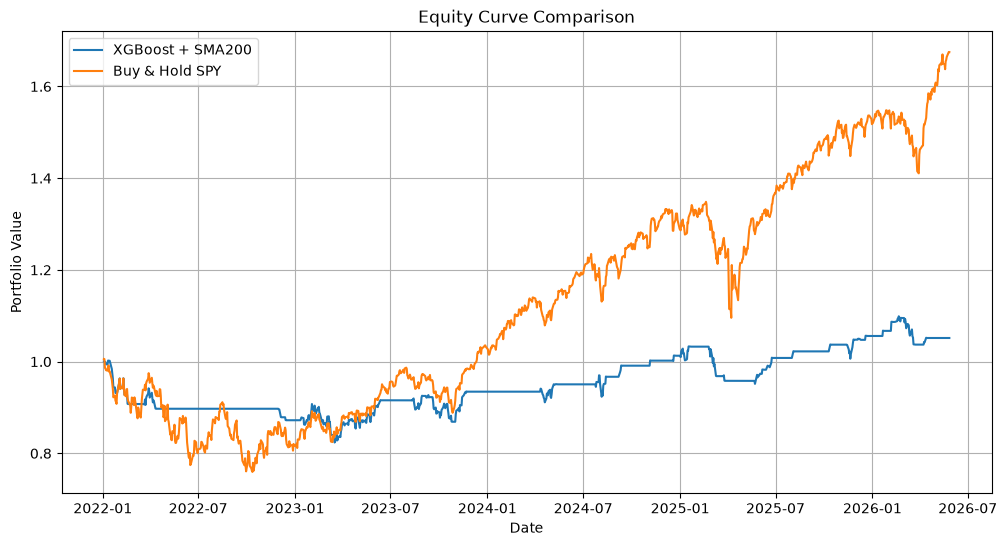

In [105]:
plt.figure(figsize=(12,6))


plt.plot(
    test_results20.index,
    test_results20["Strategy_Equity"],
    label="XGBoost + SMA200"
)


plt.plot(
    test_results20.index,
    test_results20["BuyHold_Equity"],
    label="Buy & Hold SPY"
)


plt.title(
    "Equity Curve Comparison"
)


plt.xlabel(
    "Date"
)


plt.ylabel(
    "Portfolio Value"
)


plt.legend()


plt.grid(True)


plt.show()

In [106]:
import shap


explainer = shap.TreeExplainer(
    model20
)


shap_values = explainer.shap_values(
    X_test20
)

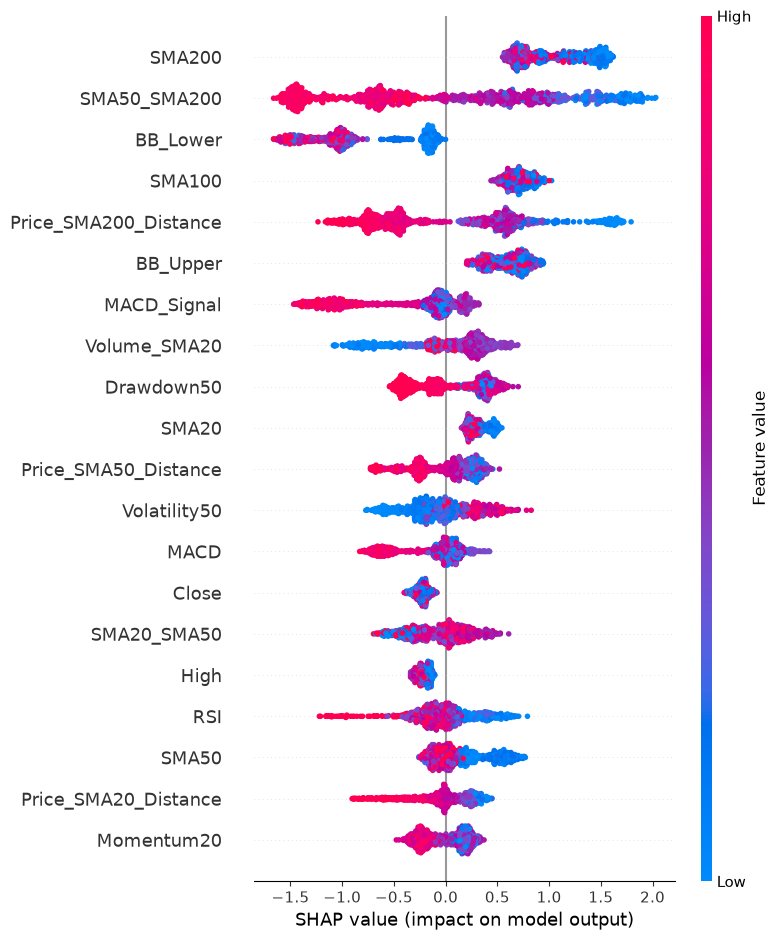

In [107]:
shap.summary_plot(
    shap_values,
    X_test20
)

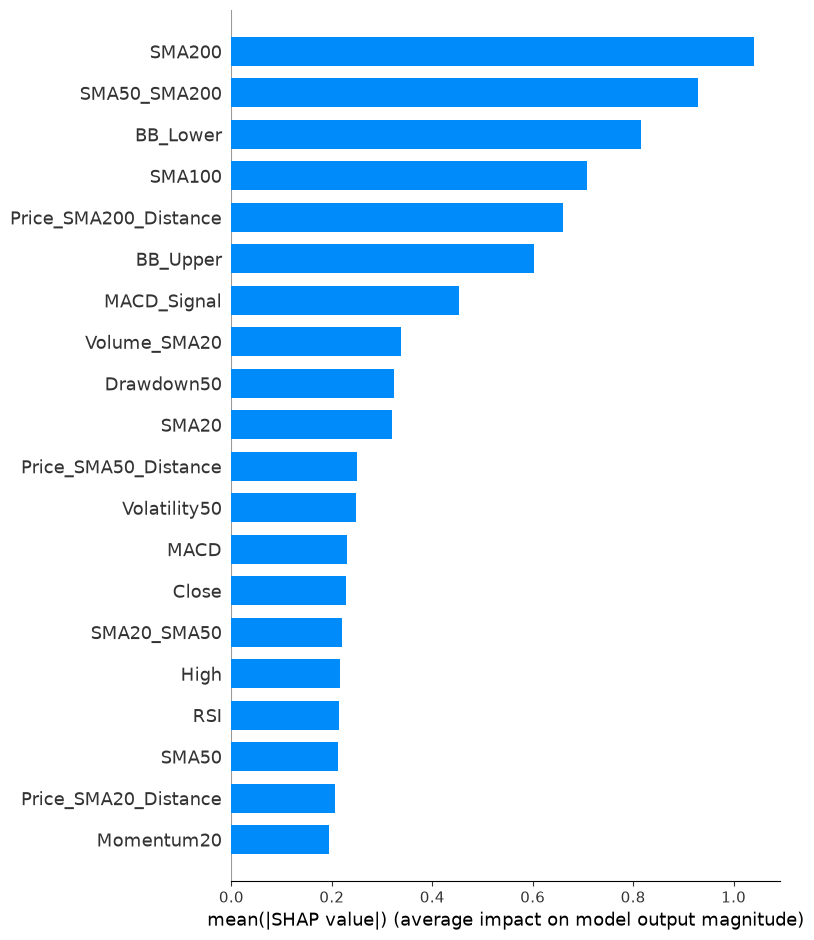

In [108]:
shap.summary_plot(
    shap_values,
    X_test20,
    plot_type="bar"
)

In [112]:
import pandas as pd


final_results = pd.DataFrame({

    "Strategy": [
        "Buy & Hold SPY",
        "XGBoost + SMA200",
        "XGBoost + SMA200 + Costs"
    ],

    "Annual Return": [
        0.1353,
        0.0262,
        0.0150
    ],

    "Annual Volatility": [
        0.1763,
        0.0828,
        0.0827
    ],

    "Sharpe Ratio": [
        0.7677,
        0.3164,
        0.1814
    ],

    "Maximum Drawdown": [
        -0.2450,
        -0.1688,
        -0.1784
    ]

})


final_results

,Strategy,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,Buy & Hold SPY,0.1353,0.1763,0.7677,-0.2450
1,XGBoost + SMA200,0.0262,0.0828,0.3164,-0.1688
2,XGBoost + SMA200 + Costs,0.0150,0.0827,0.1814,-0.1784


In [113]:
final_results.style.format({

    "Annual Return": "{:.2%}",
    "Annual Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}",
    "Maximum Drawdown": "{:.2%}"

})

,Strategy,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,Buy & Hold SPY,13.53%,17.63%,0.77,-24.50%
1,XGBoost + SMA200,2.62%,8.28%,0.32,-16.88%
2,XGBoost + SMA200 + Costs,1.50%,8.27%,0.18,-17.84%


In [114]:
import joblib


joblib.dump(
    model20,
    "xgboost_spy_model.pkl"
)

['xgboost_spy_model.pkl']